# Explainable AI (XAI) for Fraud Detection

This notebook implements **SHAP** and **LIME** explainability methods for fraud detection models.

## Objectives:
- Load preprocessed data from the data folder
- Train a tree-based model suitable for XAI analysis
- Create a reusable XAI pipeline that can be applied to different models
- Implement SHAP analysis (global and local explanations)
- Implement LIME analysis for local interpretability
- Compare SHAP vs LIME

## Notes:
- This notebook focuses on creating a complete, reusable pipeline rather than achieving optimal performance
- The pipeline can be easily adapted for other models once a satisfactory model is identified

## 1. Setup and Imports

In [1]:
# Standard libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# XAI Libraries
import shap
from lime import lime_tabular

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure matplotlib
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Preprocessed Data

We load the preprocessed data from the `../data/` folder.  
The data has already been:
- Cleaned and feature-engineered
- Split into train/val/test sets
- Scaled using RobustScaler

In [2]:
# Define data paths
DATA_DIR = Path("../data")

# Load train/val/test datasets
print("Loading preprocessed datasets...")
X_train = pd.read_parquet(DATA_DIR / "X_train.parquet")
X_val = pd.read_parquet(DATA_DIR / "X_val.parquet")
X_test = pd.read_parquet(DATA_DIR / "X_test.parquet")

y_train = pd.read_parquet(DATA_DIR / "y_train.parquet").values.ravel()
y_val = pd.read_parquet(DATA_DIR / "y_val.parquet").values.ravel()
y_test = pd.read_parquet(DATA_DIR / "y_test.parquet").values.ravel()

print(f"\nData loaded successfully!")
print(f"Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]:,} samples, {X_val.shape[1]} features")
print(f"Test set: {X_test.shape[0]:,} samples, {X_test.shape[1]} features")
print(f"\nFeatures: {list(X_train.columns)}")

# Check class distribution
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count:,} ({count/len(y_train)*100:.2f}%)")

Loading preprocessed datasets...

Data loaded successfully!
Training set: 160,000 samples, 13 features
Validation set: 20,000 samples, 13 features
Test set: 20,000 samples, 13 features

Features: ['hour', 'step', 'day', 'is_weekend', 'abs_balance_sender_error', 'large_tx', 'abs_delta_sender', 'balance_error_total', 'amount', 'delta_balance_sender', 'type_times_amount', 'balance_sender_error', 'is_cash']

Class distribution in training set:
  Class 0.0: 159,793 (99.87%)
  Class 1.0: 207 (0.13%)


## 3. Model Training

We train a tree-based model suitable for XAI analysis.  
Tree-based models are ideal for SHAP TreeExplainer, which provides fast and accurate explanations.

We'll use **XGBoost** as it:
- Performs well on tabular data
- Has excellent SHAP support
- Provides feature importance
- Is fast and efficient

In [3]:
def train_model(X_train, y_train, model_type='xgboost', **kwargs):
    """
    Train a classification model for fraud detection.
    
    Parameters:
    -----------
    X_train : pd.DataFrame
        Training features
    y_train : array-like
        Training labels
    model_type : str
        Type of model to train ('xgboost' or 'random_forest')
    **kwargs : dict
        Additional parameters for the model
    
    Returns:
    --------
    model : trained model object
    """
    print(f"\nTraining {model_type} model...")
    
    if model_type == 'xgboost':
        default_params = {
            'n_estimators': 100,
            'max_depth': 6,
            'learning_rate': 0.1,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
            'eval_metric': 'logloss',
            'use_label_encoder': False
        }
        default_params.update(kwargs)
        model = xgb.XGBClassifier(**default_params)
        
    elif model_type == 'random_forest':
        default_params = {
            'n_estimators': 100,
            'max_depth': 10,
            'min_samples_split': 5,
            'min_samples_leaf': 3,
            'max_features': 'sqrt',
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }
        default_params.update(kwargs)
        model = RandomForestClassifier(**default_params)
    
    else:
        raise ValueError(f"Unknown model_type: {model_type}")
    
    # Train the model
    model.fit(X_train, y_train)
    print(f"Model training completed!")
    
    return model

In [4]:
def evaluate_model(model, X, y, dataset_name='Test'):
    """
    Evaluate model performance on a dataset.
    
    Parameters:
    -----------
    model : trained model
        The model to evaluate
    X : pd.DataFrame
        Features
    y : array-like
        True labels
    dataset_name : str
        Name of the dataset for display
    
    Returns:
    --------
    metrics : dict
        Dictionary containing evaluation metrics
    """
    print(f"\n{'='*60}")
    print(f"Evaluation on {dataset_name} Set")
    print(f"{'='*60}")
    
    # Predictions
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, zero_division=0),
        'recall': recall_score(y, y_pred, zero_division=0),
        'f1': f1_score(y, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y, y_proba)
    }
    
    # Print metrics
    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y, y_pred, digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(f'Confusion Matrix - {dataset_name} Set')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    
    return metrics


Training xgboost model...
Model training completed!

Evaluation on Train Set

Performance Metrics:
  Accuracy:  0.9987
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  ROC-AUC:   0.9914

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9987    1.0000    0.9994    159793
         1.0     0.0000    0.0000    0.0000       207

    accuracy                         0.9987    160000
   macro avg     0.4994    0.5000    0.4997    160000
weighted avg     0.9974    0.9987    0.9981    160000



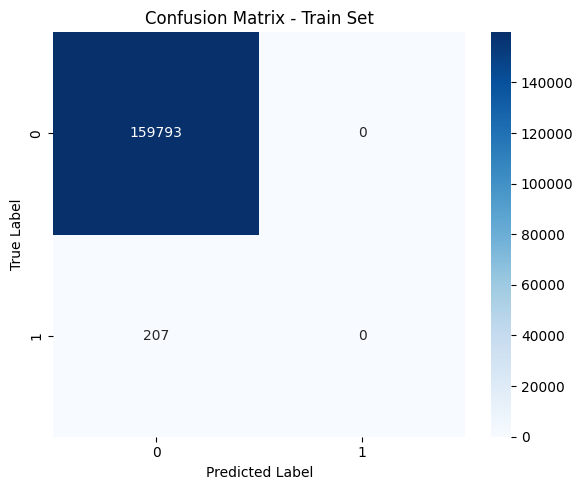


Evaluation on Test Set

Performance Metrics:
  Accuracy:  0.9987
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  ROC-AUC:   0.6076

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9987    1.0000    0.9993     19974
         1.0     0.0000    0.0000    0.0000        26

    accuracy                         0.9987     20000
   macro avg     0.4994    0.5000    0.4997     20000
weighted avg     0.9974    0.9987    0.9981     20000



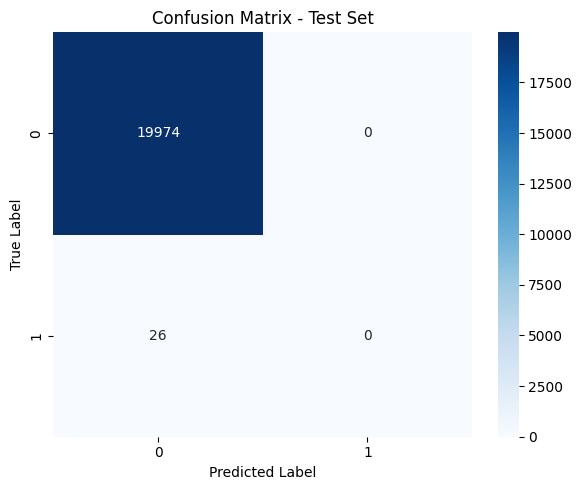

In [5]:
# Train XGBoost model
model = train_model(X_train, y_train, model_type='xgboost')

# Evaluate on train and test sets
train_metrics = evaluate_model(model, X_train, y_train, dataset_name='Train')
test_metrics = evaluate_model(model, X_test, y_test, dataset_name='Test')

## 4. SHAP Analysis

SHAP (SHapley Additive exPlanations) provides both global and local interpretability.

### 4.1 Initialize SHAP Explainer

In [6]:
class SHAPExplainer:
    """
    Reusable SHAP explainer for fraud detection models.
    """
    
    def __init__(self, model, X_background, feature_names=None, model_type='tree'):
        """
        Initialize SHAP explainer.
        
        Parameters:
        -----------
        model : trained model
            The model to explain
        X_background : pd.DataFrame or np.array
            Background data for SHAP (sample of training data)
        feature_names : list
            Names of features
        model_type : str
            Type of explainer ('tree' for tree-based models, 'kernel' for others)
        """
        self.model = model
        self.X_background = X_background
        self.feature_names = feature_names if feature_names is not None else X_background.columns.tolist()
        self.model_type = model_type
        
        print(f"Initializing SHAP {model_type} explainer...")
        
        if model_type == 'tree':
            self.explainer = shap.TreeExplainer(model)
        elif model_type == 'kernel':
            # Use a smaller background sample for kernel explainer (it's slower)
            background_sample = shap.sample(X_background, min(100, len(X_background)))
            self.explainer = shap.KernelExplainer(model.predict_proba, background_sample)
        else:
            raise ValueError(f"Unknown model_type: {model_type}")
        
        self.shap_values = None
        self.X_explained = None
        
        print("SHAP explainer initialized!")
    
    def compute_shap_values(self, X, max_samples=None):
        """
        Compute SHAP values for a dataset.
        
        Parameters:
        -----------
        X : pd.DataFrame
            Data to explain
        max_samples : int
            Maximum number of samples to explain (for performance)
        
        Returns:
        --------
        shap_values : array
            SHAP values
        """
        if max_samples is not None and len(X) > max_samples:
            X = X.sample(n=max_samples, random_state=RANDOM_STATE)
        
        print(f"Computing SHAP values for {len(X)} samples...")
        self.X_explained = X
        self.shap_values = self.explainer.shap_values(X)
        
        # For binary classification, extract positive class SHAP values
        if isinstance(self.shap_values, list):
            self.shap_values = self.shap_values[1]
        
        print("SHAP values computed!")
        return self.shap_values
    
    def plot_summary(self, plot_type='dot', max_display=20):
        """
        Create SHAP summary plot (global feature importance).
        
        Parameters:
        -----------
        plot_type : str
            Type of plot ('dot' or 'bar')
        max_display : int
            Maximum number of features to display
        """
        if self.shap_values is None:
            raise ValueError("SHAP values not computed yet. Call compute_shap_values() first.")
        
        print(f"\nGenerating SHAP summary plot ({plot_type})...")
        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            self.shap_values, 
            self.X_explained,
            plot_type=plot_type,
            max_display=max_display,
            show=False
        )
        plt.title(f"SHAP Feature Importance ({plot_type.capitalize()} Plot)", fontsize=14, pad=20)
        plt.tight_layout()
        plt.show()
    
    def plot_waterfall(self, sample_idx=0):
        """
        Create SHAP waterfall plot for a single prediction (local explanation).
        
        Parameters:
        -----------
        sample_idx : int
            Index of the sample to explain
        """
        if self.shap_values is None:
            raise ValueError("SHAP values not computed yet. Call compute_shap_values() first.")
        
        print(f"\nGenerating SHAP waterfall plot for sample {sample_idx}...")
        
        # Create explanation object for waterfall plot
        explanation = shap.Explanation(
            values=self.shap_values[sample_idx],
            base_values=self.explainer.expected_value if not isinstance(self.explainer.expected_value, np.ndarray) else self.explainer.expected_value[1],
            data=self.X_explained.iloc[sample_idx].values,
            feature_names=self.feature_names
        )
        
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(explanation, show=False)
        plt.title(f"SHAP Waterfall Plot - Sample {sample_idx}", fontsize=14, pad=20)
        plt.tight_layout()
        plt.show()
    
    def plot_force(self, sample_idx=0):
        """
        Create SHAP force plot for a single prediction (local explanation).
        
        Parameters:
        -----------
        sample_idx : int
            Index of the sample to explain
        """
        if self.shap_values is None:
            raise ValueError("SHAP values not computed yet. Call compute_shap_values() first.")
        
        print(f"\nGenerating SHAP force plot for sample {sample_idx}...")
        
        base_value = self.explainer.expected_value
        if isinstance(base_value, np.ndarray):
            base_value = base_value[1]
        
        shap.force_plot(
            base_value,
            self.shap_values[sample_idx],
            self.X_explained.iloc[sample_idx],
            matplotlib=True,
            show=False
        )
        plt.title(f"SHAP Force Plot - Sample {sample_idx}", fontsize=14)
        plt.tight_layout()
        plt.show()
    
    def explain_samples(self, sample_indices, y_true=None, y_pred=None):
        """
        Provide detailed explanation for multiple samples.
        
        Parameters:
        -----------
        sample_indices : list
            List of sample indices to explain
        y_true : array-like
            True labels (optional)
        y_pred : array-like
            Predicted labels (optional)
        """
        if self.shap_values is None:
            raise ValueError("SHAP values not computed yet. Call compute_shap_values() first.")
        
        for idx in sample_indices:
            print(f"\n{'='*60}")
            print(f"Explanation for Sample {idx}")
            print(f"{'='*60}")
            
            if y_true is not None:
                print(f"True Label: {y_true[idx]}")
            if y_pred is not None:
                print(f"Predicted Label: {y_pred[idx]}")
            
            print(f"\nFeature Values:")
            for feature, value in zip(self.feature_names, self.X_explained.iloc[idx].values):
                shap_val = self.shap_values[idx][self.feature_names.index(feature)]
                print(f"  {feature:25s}: {value:10.4f}  (SHAP: {shap_val:+.4f})")
            
            # Show waterfall plot
            self.plot_waterfall(idx)

In [7]:
# Create SHAP explainer
# Use a sample of training data as background (for efficiency)
background_data = X_train.sample(n=min(1000, len(X_train)), random_state=RANDOM_STATE)
shap_explainer = SHAPExplainer(model, background_data, model_type='tree')

# Compute SHAP values for test set (sample for efficiency)
shap_values = shap_explainer.compute_shap_values(X_test, max_samples=1000)

Initializing SHAP tree explainer...
SHAP explainer initialized!
Computing SHAP values for 1000 samples...
SHAP values computed!


### 4.2 Global SHAP Explanations

Global explanations show which features are most important overall for fraud detection.


Generating SHAP summary plot (dot)...


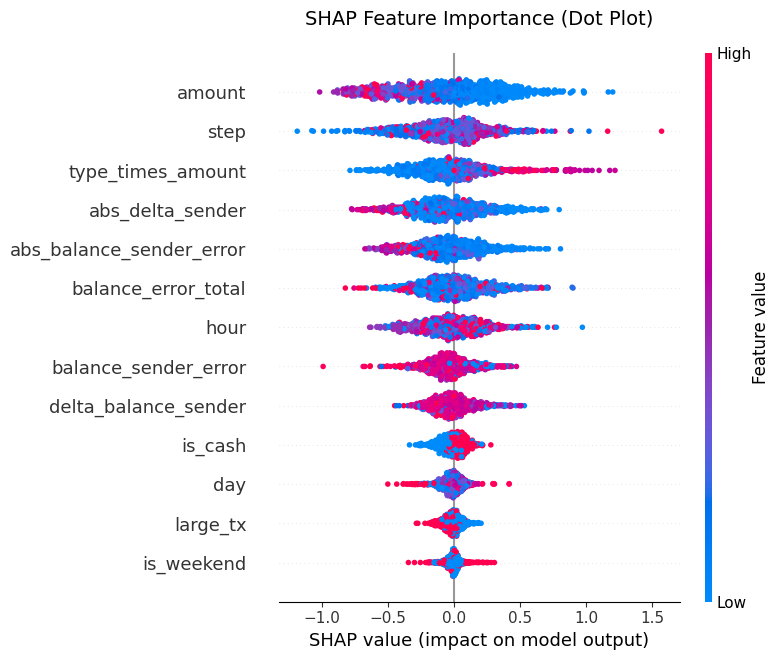

In [8]:
# SHAP summary plot (dot plot) - shows feature importance and impact
shap_explainer.plot_summary(plot_type='dot', max_display=15)


Generating SHAP summary plot (bar)...


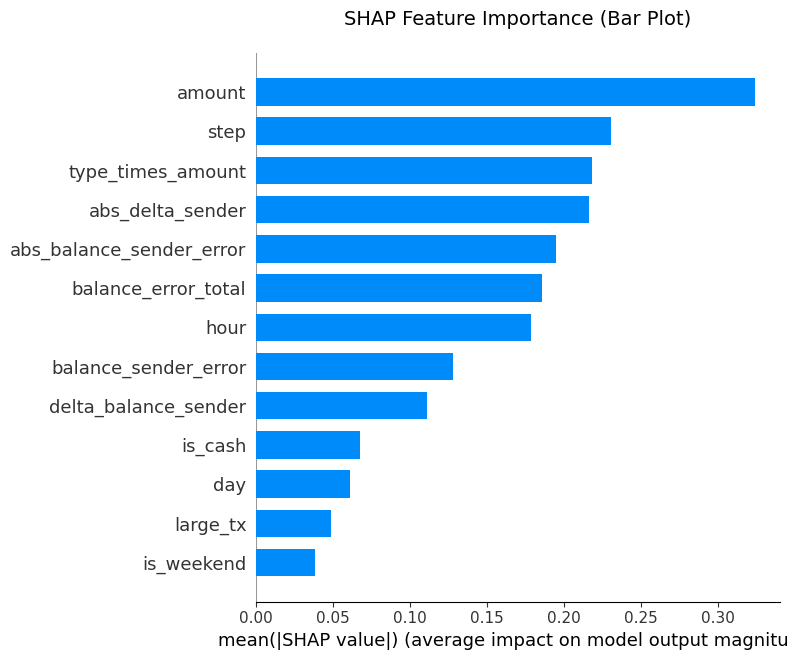

In [9]:
# SHAP summary plot (bar plot) - shows mean absolute SHAP values
shap_explainer.plot_summary(plot_type='bar', max_display=15)

### 4.3 Local SHAP Explanations

Local explanations show how features contribute to individual predictions.

In [10]:
# Get predictions on test samples
y_test_pred = model.predict(shap_explainer.X_explained)
y_test_proba = model.predict_proba(shap_explainer.X_explained)[:, 1]

# Find indices of fraud cases (true positives and false positives)
y_test_subset = y_test[shap_explainer.X_explained.index]
fraud_indices = np.where(y_test_subset == 1)[0]
predicted_fraud_indices = np.where(y_test_pred == 1)[0]

print(f"Number of actual fraud cases in sample: {len(fraud_indices)}")
print(f"Number of predicted fraud cases in sample: {len(predicted_fraud_indices)}")

# Select interesting samples to explain
if len(fraud_indices) > 0:
    sample_to_explain = fraud_indices[0]
    print(f"\nExplaining a true fraud case (index {sample_to_explain})...")
else:
    # If no fraud in sample, pick a high-confidence fraud prediction
    sample_to_explain = np.argmax(y_test_proba)
    print(f"\nExplaining highest fraud probability case (index {sample_to_explain})...")

Number of actual fraud cases in sample: 0
Number of predicted fraud cases in sample: 0

Explaining highest fraud probability case (index 518)...



Generating SHAP waterfall plot for sample 518...


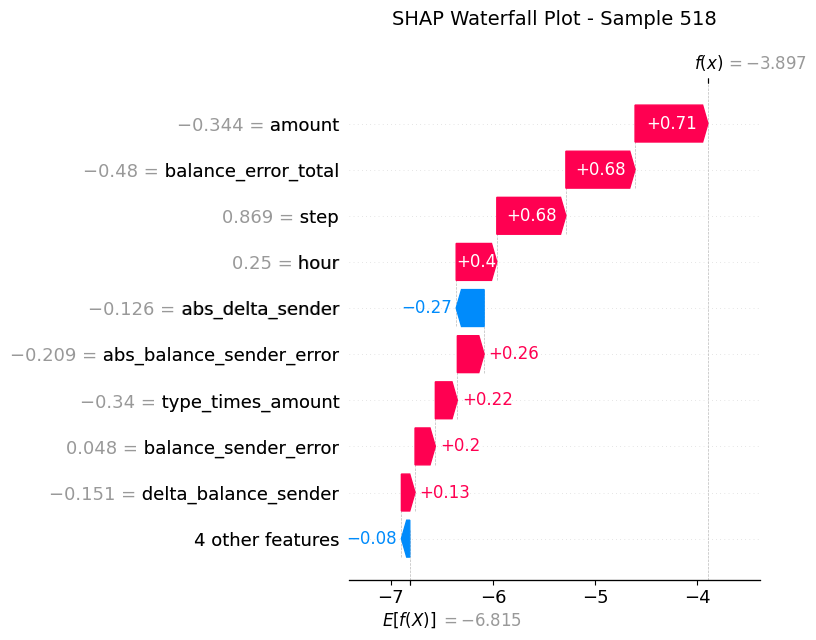

In [11]:
# Waterfall plot for a fraud case
shap_explainer.plot_waterfall(sample_to_explain)


Generating SHAP force plot for sample 518...


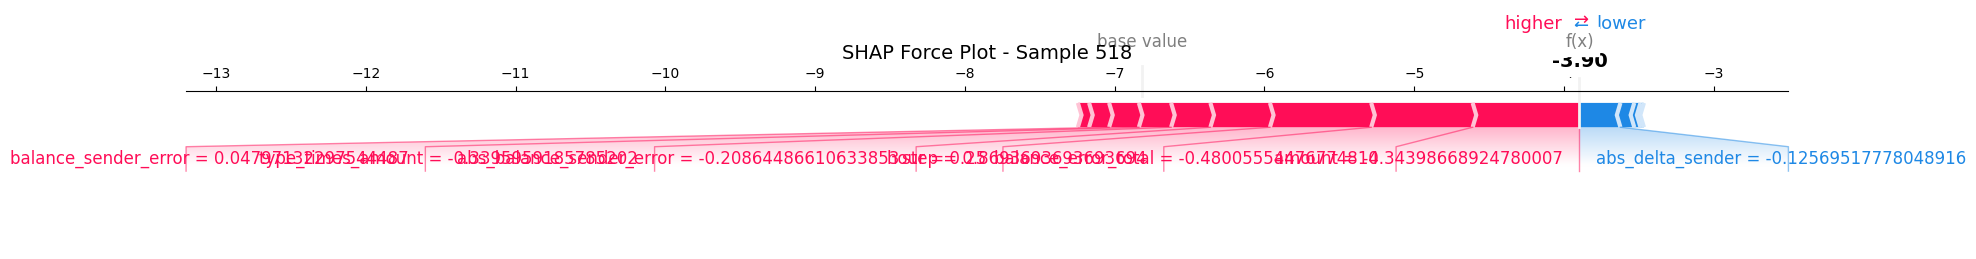

In [12]:
# Force plot for a fraud case
shap_explainer.plot_force(sample_to_explain)


Explanation for Sample 158
True Label: 0.0
Predicted Label: 0

Feature Values:
  hour                     :    -0.6667  (SHAP: -0.0662)
  step                     :     0.6036  (SHAP: +0.2875)
  day                      :     0.6667  (SHAP: +0.0425)
  is_weekend               :     0.0000  (SHAP: +0.0067)
  abs_balance_sender_error :     0.8623  (SHAP: +0.4707)
  large_tx                 :     0.0000  (SHAP: -0.0132)
  abs_delta_sender         :     0.8488  (SHAP: +0.2498)
  balance_error_total      :     1.9268  (SHAP: +0.6382)
  amount                   :     0.1091  (SHAP: +0.1251)
  delta_balance_sender     :    -1.6306  (SHAP: +0.2088)
  type_times_amount        :     0.1772  (SHAP: +0.3612)
  balance_sender_error     :    -1.3613  (SHAP: +0.1442)
  is_cash                  :     0.0000  (SHAP: +0.0437)

Generating SHAP waterfall plot for sample 158...


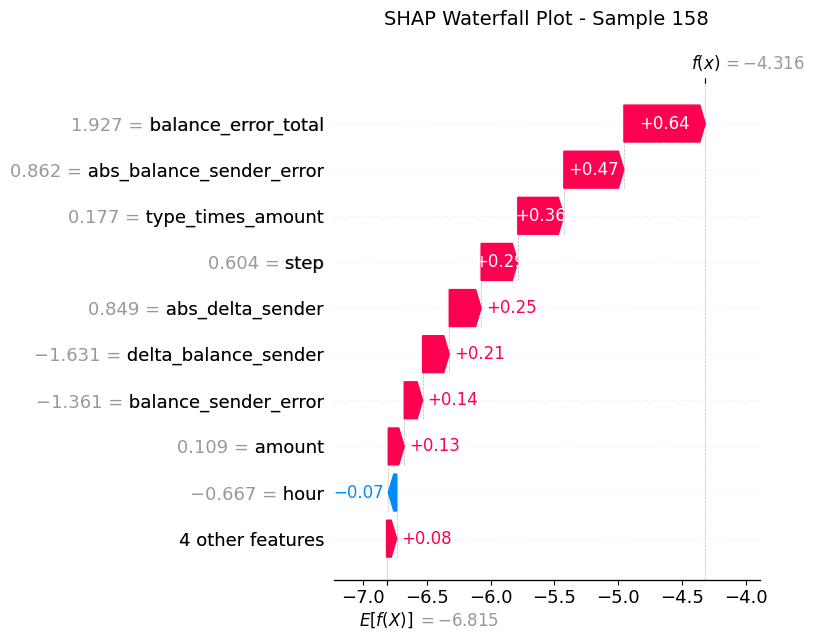


Explanation for Sample 492
True Label: 0.0
Predicted Label: 0

Feature Values:
  hour                     :     0.0833  (SHAP: -0.0473)
  step                     :     1.6171  (SHAP: +1.1648)
  day                      :     1.6667  (SHAP: +0.2181)
  is_weekend               :     0.0000  (SHAP: +0.0591)
  abs_balance_sender_error :    -0.3329  (SHAP: -0.1153)
  large_tx                 :     1.0000  (SHAP: +0.0020)
  abs_delta_sender         :    -0.2682  (SHAP: +0.6575)
  balance_error_total      :    -0.2521  (SHAP: +0.1113)
  amount                   :    -0.1513  (SHAP: +0.2150)
  delta_balance_sender     :     0.0654  (SHAP: -0.0096)
  type_times_amount        :    -0.1177  (SHAP: -0.0204)
  balance_sender_error     :     0.2114  (SHAP: -0.0080)
  is_cash                  :     0.0000  (SHAP: +0.2802)

Generating SHAP waterfall plot for sample 492...


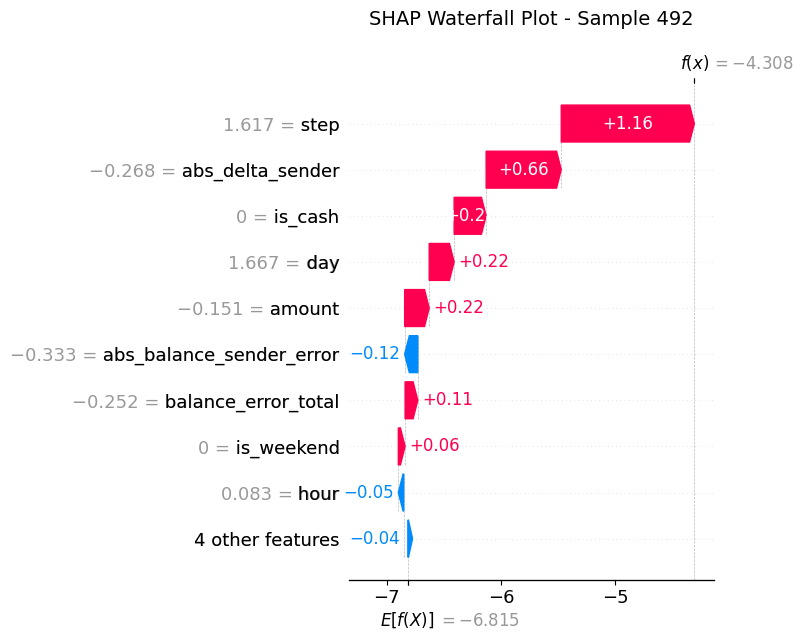


Explanation for Sample 518
True Label: 0.0
Predicted Label: 0

Feature Values:
  hour                     :     0.2500  (SHAP: +0.3976)
  step                     :     0.8694  (SHAP: +0.6761)
  day                      :     0.8889  (SHAP: +0.0745)
  is_weekend               :     0.0000  (SHAP: -0.0229)
  abs_balance_sender_error :    -0.2086  (SHAP: +0.2622)
  large_tx                 :     1.0000  (SHAP: -0.0415)
  abs_delta_sender         :    -0.1257  (SHAP: -0.2735)
  balance_error_total      :    -0.4801  (SHAP: +0.6772)
  amount                   :    -0.3440  (SHAP: +0.7133)
  delta_balance_sender     :    -0.1510  (SHAP: +0.1337)
  type_times_amount        :    -0.3396  (SHAP: +0.2153)
  balance_sender_error     :     0.0480  (SHAP: +0.1986)
  is_cash                  :    -1.0000  (SHAP: -0.0923)

Generating SHAP waterfall plot for sample 518...


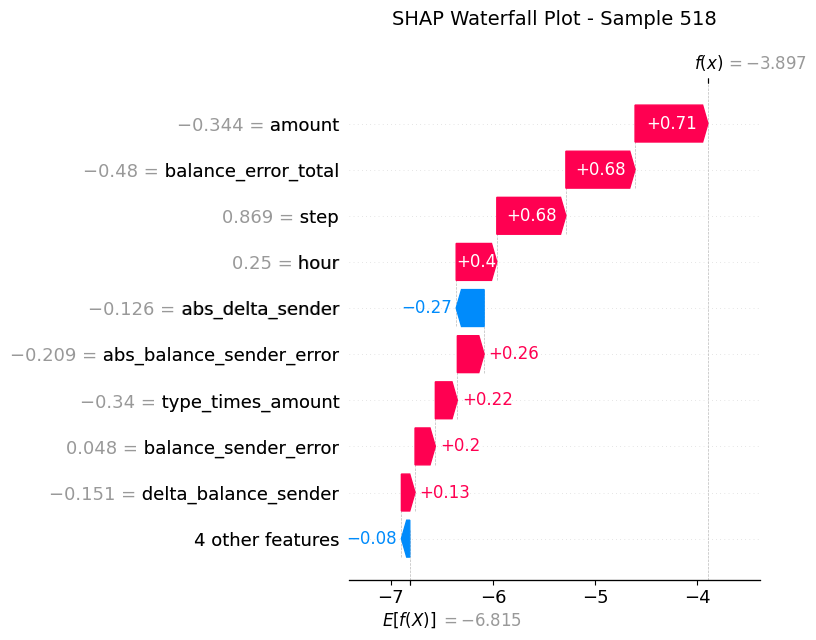

In [13]:
# Explain multiple samples (e.g., first 3 fraud cases)
if len(fraud_indices) >= 3:
    samples_to_explain = fraud_indices[:3].tolist()
else:
    # Pick top 3 fraud predictions
    samples_to_explain = np.argsort(y_test_proba)[-3:].tolist()

shap_explainer.explain_samples(
    samples_to_explain, 
    y_true=y_test_subset, 
    y_pred=y_test_pred
)

## 5. LIME Analysis

LIME (Local Interpretable Model-agnostic Explanations) provides local interpretability by approximating the model locally with an interpretable model.

### 5.1 Initialize LIME Explainer

In [14]:
class LIMEExplainer:
    """
    Reusable LIME explainer for fraud detection models.
    """
    
    def __init__(self, model, X_train, feature_names=None, class_names=None):
        """
        Initialize LIME explainer.
        
        Parameters:
        -----------
        model : trained model
            The model to explain
        X_train : pd.DataFrame or np.array
            Training data (used to understand feature distributions)
        feature_names : list
            Names of features
        class_names : list
            Names of classes
        """
        self.model = model
        self.feature_names = feature_names if feature_names is not None else X_train.columns.tolist()
        self.class_names = class_names if class_names is not None else ['Non-Fraud', 'Fraud']
        
        print(f"Initializing LIME explainer...")
        
        self.explainer = lime_tabular.LimeTabularExplainer(
            training_data=X_train.values if isinstance(X_train, pd.DataFrame) else X_train,
            feature_names=self.feature_names,
            class_names=self.class_names,
            mode='classification',
            random_state=RANDOM_STATE
        )
        
        print("LIME explainer initialized!")
    
    def explain_instance(self, X, sample_idx, num_features=10):
        """
        Explain a single prediction using LIME.
        
        Parameters:
        -----------
        X : pd.DataFrame
            Data containing the sample to explain
        sample_idx : int
            Index of the sample to explain
        num_features : int
            Number of features to show in explanation
        
        Returns:
        --------
        explanation : lime.explanation.Explanation
            LIME explanation object
        """
        print(f"\nGenerating LIME explanation for sample {sample_idx}...")
        
        if isinstance(X, pd.DataFrame):
            sample = X.iloc[sample_idx].values
        else:
            sample = X[sample_idx]
        
        explanation = self.explainer.explain_instance(
            data_row=sample,
            predict_fn=self.model.predict_proba,
            num_features=num_features
        )
        
        return explanation
    
    def plot_explanation(self, explanation, sample_idx):
        """
        Plot LIME explanation.
        
        Parameters:
        -----------
        explanation : lime.explanation.Explanation
            LIME explanation object
        sample_idx : int
            Index of the sample (for title)
        """
        # Get explanation for fraud class (class 1)
        exp_list = explanation.as_list(label=1)
        
        # Extract features and weights
        features = [item[0] for item in exp_list]
        weights = [item[1] for item in exp_list]
        
        # Create horizontal bar plot
        fig, ax = plt.subplots(figsize=(10, 6))
        
        colors = ['red' if w < 0 else 'green' for w in weights]
        y_pos = np.arange(len(features))
        
        ax.barh(y_pos, weights, color=colors, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(features)
        ax.set_xlabel('Feature Weight (Impact on Fraud Prediction)', fontsize=12)
        ax.set_title(f'LIME Explanation - Sample {sample_idx}\n(Green = increases fraud probability, Red = decreases)', 
                     fontsize=14, pad=20)
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print prediction probabilities
        proba = explanation.predict_proba
        print(f"\nPrediction Probabilities:")
        for class_idx, class_name in enumerate(self.class_names):
            print(f"  {class_name}: {proba[class_idx]:.4f}")
    
    def explain_samples(self, X, sample_indices, num_features=10, y_true=None, y_pred=None):
        """
        Explain multiple samples using LIME.
        
        Parameters:
        -----------
        X : pd.DataFrame
            Data containing samples
        sample_indices : list
            List of sample indices to explain
        num_features : int
            Number of features to show in each explanation
        y_true : array-like
            True labels (optional)
        y_pred : array-like
            Predicted labels (optional)
        
        Returns:
        --------
        explanations : list
            List of LIME explanation objects
        """
        explanations = []
        
        for idx in sample_indices:
            print(f"\n{'='*60}")
            print(f"LIME Explanation for Sample {idx}")
            print(f"{'='*60}")

            true_label = int(round(y_true[idx]))
            pred_label = int(round(y_pred[idx]))
            
            if y_true is not None:
                print(f"True Label: {self.class_names[true_label]}")
            if y_pred is not None:
                print(f"Predicted Label: {self.class_names[pred_label]}")
            
            explanation = self.explain_instance(X, idx, num_features)
            self.plot_explanation(explanation, idx)
            explanations.append(explanation)
        
        return explanations

In [15]:
# Create LIME explainer
# Use training data to understand feature distributions
lime_explainer = LIMEExplainer(model, X_train)

Initializing LIME explainer...
LIME explainer initialized!


### 5.2 Local LIME Explanations

LIME provides local explanations by fitting a simple interpretable model around each prediction.

In [16]:
# Use same samples as SHAP for comparison
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)
y_test_sample = y_test[X_test_sample.index]
y_pred_sample = model.predict(X_test_sample)

# Find fraud cases
fraud_indices_lime = np.where(y_test_sample == 1)[0]

if len(fraud_indices_lime) > 0:
    sample_idx = fraud_indices_lime[0]
else:
    # Pick highest fraud probability
    y_proba_sample = model.predict_proba(X_test_sample)[:, 1]
    sample_idx = np.argmax(y_proba_sample)

print(f"Selected sample index: {sample_idx}")
print(f"True label: {y_test_sample[sample_idx]}")
print(f"Predicted label: {y_pred_sample[sample_idx]}")

Selected sample index: 518
True label: 0.0
Predicted label: 0



Generating LIME explanation for sample 518...


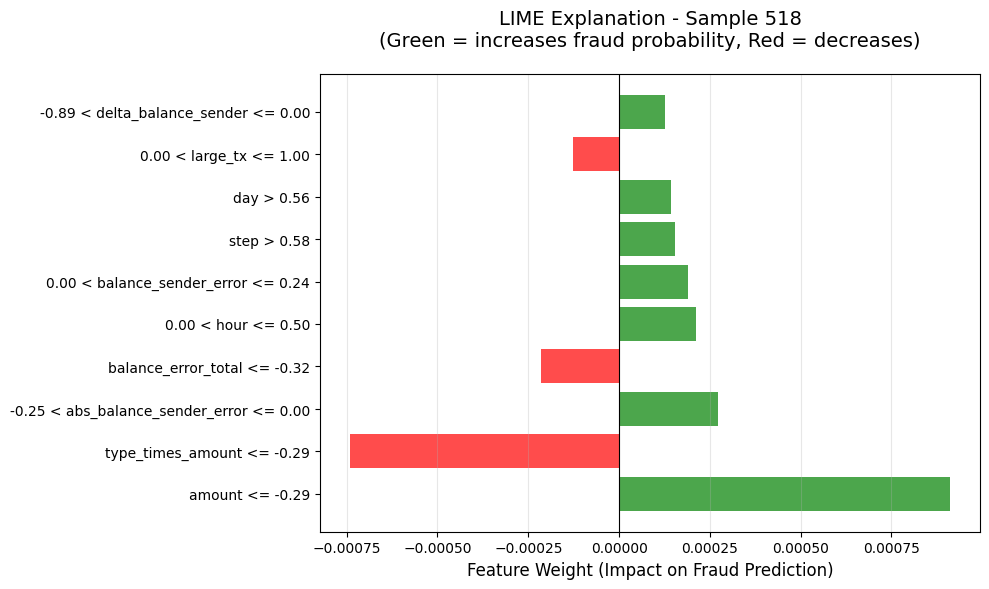


Prediction Probabilities:
  Non-Fraud: 0.9801
  Fraud: 0.0199


In [17]:
# Explain a single instance
explanation = lime_explainer.explain_instance(X_test_sample, sample_idx, num_features=10)
lime_explainer.plot_explanation(explanation, sample_idx)


LIME Explanation for Sample 158
True Label: Non-Fraud
Predicted Label: Non-Fraud

Generating LIME explanation for sample 158...


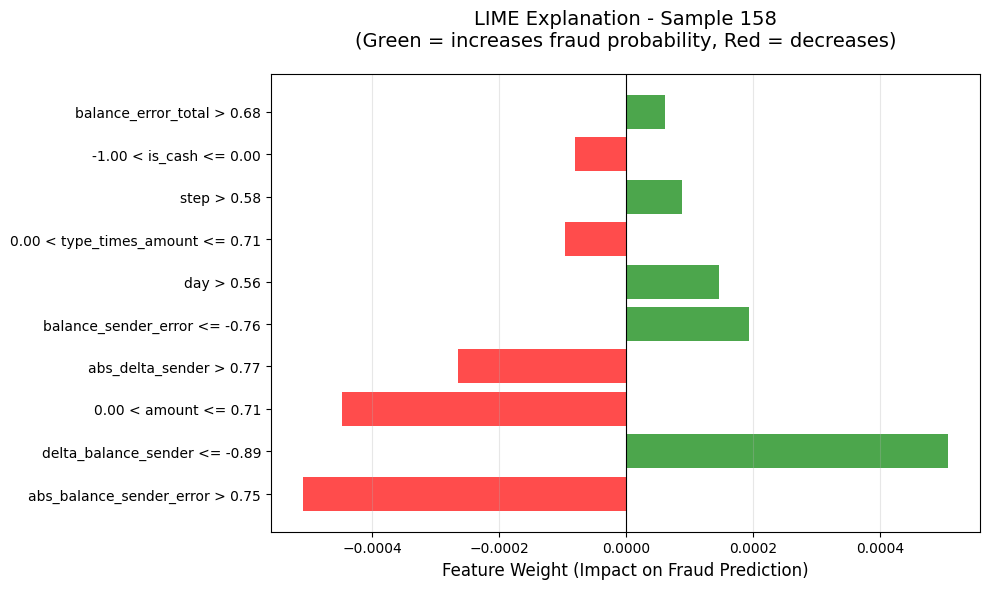


Prediction Probabilities:
  Non-Fraud: 0.9868
  Fraud: 0.0132

LIME Explanation for Sample 492
True Label: Non-Fraud
Predicted Label: Non-Fraud

Generating LIME explanation for sample 492...


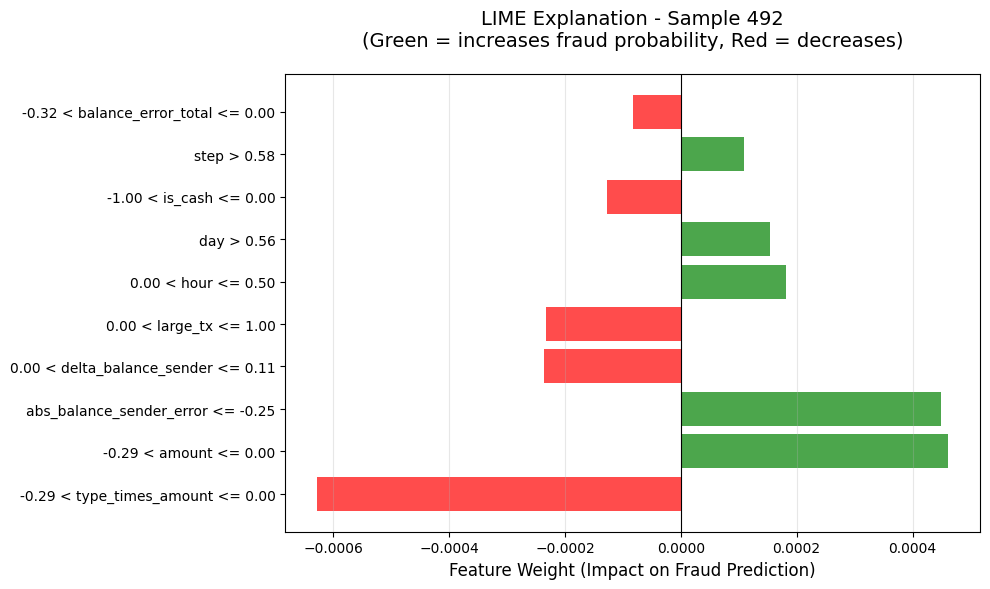


Prediction Probabilities:
  Non-Fraud: 0.9867
  Fraud: 0.0133

LIME Explanation for Sample 518
True Label: Non-Fraud
Predicted Label: Non-Fraud

Generating LIME explanation for sample 518...


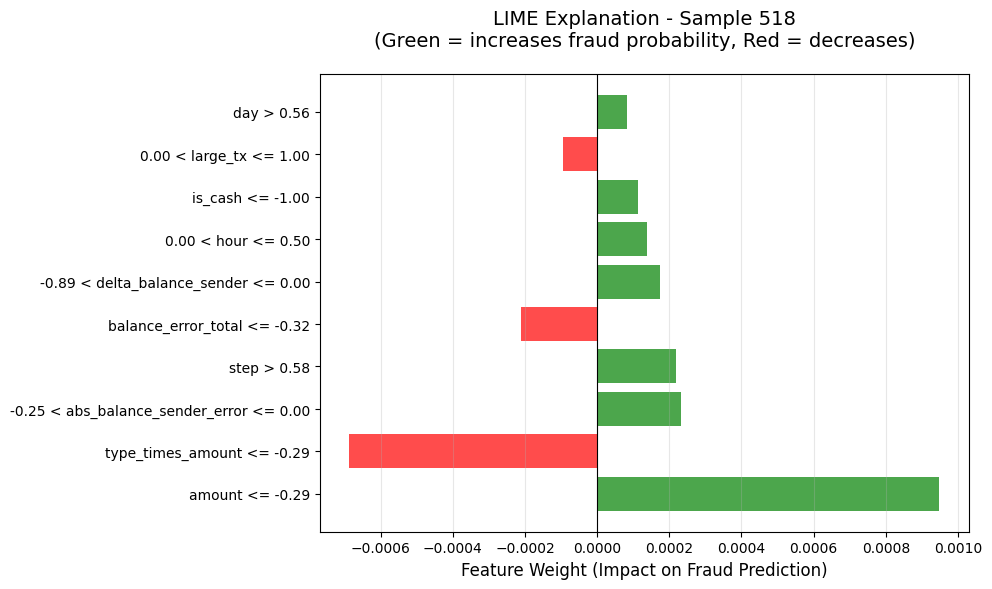


Prediction Probabilities:
  Non-Fraud: 0.9801
  Fraud: 0.0199


In [18]:
# Explain multiple samples
if len(fraud_indices_lime) >= 3:
    samples_to_explain_lime = fraud_indices_lime[:3].tolist()
else:
    y_proba_sample = model.predict_proba(X_test_sample)[:, 1]
    samples_to_explain_lime = np.argsort(y_proba_sample)[-3:].tolist()

lime_explanations = lime_explainer.explain_samples(
    X_test_sample,
    samples_to_explain_lime,
    num_features=10,
    y_true=y_test_sample,
    y_pred=y_pred_sample
)

## 6. Comparison: SHAP vs LIME

Let's compare SHAP and LIME explanations for the same samples to understand their similarities and differences.

### Key Differences:

**SHAP:**
- Based on game theory (Shapley values)
- Provides consistent and theoretically sound explanations
- TreeExplainer is very fast for tree-based models
- Global and local explanations available
- Shows actual feature contributions to prediction

**LIME:**
- Model-agnostic approach
- Approximates model locally with interpretable model
- Can be slower, especially for complex models
- Only local explanations
- May give different explanations on repeated runs (due to sampling)

### Comparison Criteria:
1. **Consistency**: Do both methods identify similar important features?
2. **Interpretability**: Which method is easier to understand for auditors?
3. **Robustness**: How stable are the explanations?
4. **Computational Cost**: Which is faster?

In [19]:
def compare_shap_lime(shap_explainer, lime_explainer, X, sample_idx, y_true=None, y_pred=None):
    """
    Compare SHAP and LIME explanations for the same sample.
    
    Parameters:
    -----------
    shap_explainer : SHAPExplainer
        SHAP explainer object
    lime_explainer : LIMEExplainer
        LIME explainer object
    X : pd.DataFrame
        Data containing the sample
    sample_idx : int
        Index of the sample to explain
    y_true : int
        True label (optional)
    y_pred : int
        Predicted label (optional)
    """
    print(f"\n{'='*80}")
    print(f"SHAP vs LIME Comparison - Sample {sample_idx}")
    print(f"{'='*80}")
    
    if y_true is not None:
        print(f"True Label: {y_true}")
    if y_pred is not None:
        print(f"Predicted Label: {y_pred}")
    
    # SHAP explanation
    print(f"\n{'-'*80}")
    print("SHAP Explanation:")
    print(f"{'-'*80}")
    shap_explainer.plot_waterfall(sample_idx)
    
    # LIME explanation
    print(f"\n{'-'*80}")
    print("LIME Explanation:")
    print(f"{'-'*80}")
    lime_explanation = lime_explainer.explain_instance(X, sample_idx, num_features=10)
    lime_explainer.plot_explanation(lime_explanation, sample_idx)
    
    # Feature importance comparison
    print(f"\n{'-'*80}")
    print("Feature Importance Comparison:")
    print(f"{'-'*80}")
    
    # Get SHAP values for this sample
    shap_values_sample = shap_explainer.shap_values[sample_idx]
    shap_importance = pd.DataFrame({
        'Feature': shap_explainer.feature_names,
        'SHAP_Value': shap_values_sample
    }).sort_values('SHAP_Value', key=abs, ascending=False).head(10)
    
    # Get LIME weights
    lime_weights = lime_explanation.as_list(label=1)
    lime_df = pd.DataFrame(lime_weights, columns=['Feature', 'LIME_Weight'])
    
    print("\nTop 10 Features by Absolute Importance:")
    print("\nSHAP:")
    for idx, row in shap_importance.iterrows():
        print(f"  {row['Feature']:25s}: {row['SHAP_Value']:+.4f}")
    
    print("\nLIME:")
    for _, row in lime_df.iterrows():
        print(f"  {row['Feature']:25s}: {row['LIME_Weight']:+.4f}")
    
    return shap_importance, lime_df

Computing SHAP values for comparison...
Initializing SHAP tree explainer...
SHAP explainer initialized!
Computing SHAP values for 1000 samples...
SHAP values computed!

SHAP vs LIME Comparison - Sample 518
True Label: 0.0
Predicted Label: 0

--------------------------------------------------------------------------------
SHAP Explanation:
--------------------------------------------------------------------------------

Generating SHAP waterfall plot for sample 518...


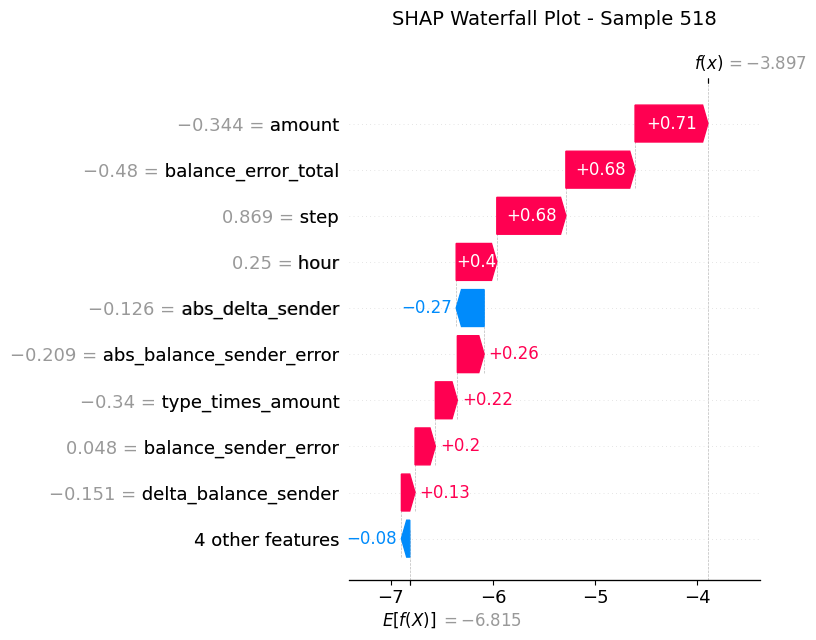


--------------------------------------------------------------------------------
LIME Explanation:
--------------------------------------------------------------------------------

Generating LIME explanation for sample 518...


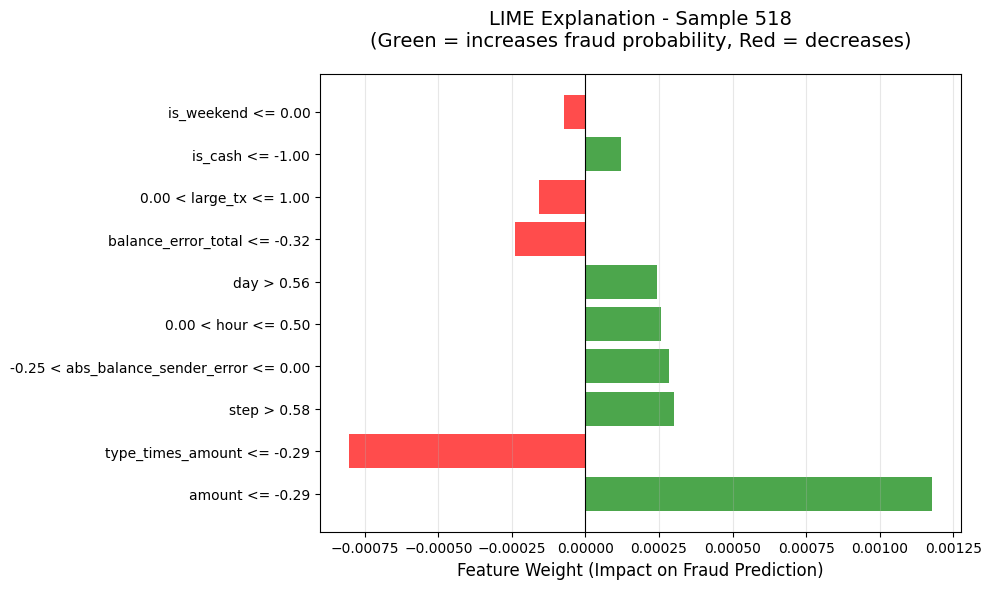


Prediction Probabilities:
  Non-Fraud: 0.9801
  Fraud: 0.0199

--------------------------------------------------------------------------------
Feature Importance Comparison:
--------------------------------------------------------------------------------

Top 10 Features by Absolute Importance:

SHAP:
  amount                   : +0.7133
  balance_error_total      : +0.6772
  step                     : +0.6761
  hour                     : +0.3976
  abs_delta_sender         : -0.2735
  abs_balance_sender_error : +0.2622
  type_times_amount        : +0.2153
  balance_sender_error     : +0.1986
  delta_balance_sender     : +0.1337
  is_cash                  : -0.0923

LIME:
  amount <= -0.29          : +0.0012
  type_times_amount <= -0.29: -0.0008
  step > 0.58              : +0.0003
  -0.25 < abs_balance_sender_error <= 0.00: +0.0003
  0.00 < hour <= 0.50      : +0.0003
  day > 0.56               : +0.0002
  balance_error_total <= -0.32: -0.0002
  0.00 < large_tx <= 1.00  : -0.0002
  i

In [20]:
# Select a sample that's in both SHAP and LIME explained datasets
# We need to work with the intersection of indices

# For simplicity, let's re-compute SHAP on the same test sample as LIME
print("Computing SHAP values for comparison...")
shap_explainer_compare = SHAPExplainer(model, background_data, model_type='tree')
shap_values_compare = shap_explainer_compare.compute_shap_values(X_test_sample, max_samples=None)

# Compare for the same sample
if len(fraud_indices_lime) > 0:
    comparison_idx = fraud_indices_lime[0]
else:
    comparison_idx = sample_idx

shap_imp, lime_imp = compare_shap_lime(
    shap_explainer_compare,
    lime_explainer,
    X_test_sample,
    comparison_idx,
    y_true=y_test_sample[comparison_idx],
    y_pred=y_pred_sample[comparison_idx]
)

## 7. Summary and Recommendations

### When to Use SHAP:
- For tree-based models (very fast with TreeExplainer)
- When you need both global and local explanations
- When theoretical soundness is important
- For consistent and reproducible explanations

### When to Use LIME:
- For any model type (model-agnostic)
- When you only need local explanations
- When simplicity and intuitiveness are priorities
- For explaining individual borderline cases

### For Auditors:
- **SHAP** provides rigorous, mathematically grounded explanations
- **LIME** offers intuitive, easy-to-understand local explanations
- Both methods should be used together for comprehensive explainability
- SHAP for overall model behavior, LIME for individual suspicious transactions

## 8. Reusable XAI Pipeline

This section provides a complete reusable pipeline that can be applied to any model.

In [21]:
def complete_xai_pipeline(model, X_train, X_test, y_test, 
                         model_type='tree', 
                         num_samples_explain=5,
                         shap_background_size=1000,
                         test_sample_size=1000):
    """
    Complete XAI pipeline for fraud detection model.
    
    Parameters:
    -----------
    model : trained model
        The fraud detection model to explain
    X_train : pd.DataFrame
        Training features
    X_test : pd.DataFrame
        Test features
    y_test : array-like
        Test labels
    model_type : str
        Type of model ('tree' or 'kernel' for SHAP)
    num_samples_explain : int
        Number of individual samples to explain
    shap_background_size : int
        Size of background data for SHAP
    test_sample_size : int
        Size of test sample to explain
    
    Returns:
    --------
    results : dict
        Dictionary containing explainers and explanations
    """
    print("="*80)
    print("COMPLETE XAI PIPELINE FOR FRAUD DETECTION")
    print("="*80)
    
    # Sample test data if needed
    if len(X_test) > test_sample_size:
        test_indices = np.random.choice(len(X_test), test_sample_size, replace=False)
        X_test_sample = X_test.iloc[test_indices]
        y_test_sample = y_test[test_indices]
    else:
        X_test_sample = X_test
        y_test_sample = y_test
    
    # Get predictions
    y_pred = model.predict(X_test_sample)
    y_proba = model.predict_proba(X_test_sample)[:, 1]
    
    # ========== SHAP Analysis ==========
    print("\n" + "="*80)
    print("SHAP ANALYSIS")
    print("="*80)
    
    # Initialize SHAP
    background_data = X_train.sample(n=min(shap_background_size, len(X_train)), random_state=RANDOM_STATE)
    shap_exp = SHAPExplainer(model, background_data, model_type=model_type)
    shap_values = shap_exp.compute_shap_values(X_test_sample)
    
    # Global SHAP
    print("\n" + "-"*80)
    print("Global SHAP Explanations")
    print("-"*80)
    shap_exp.plot_summary(plot_type='dot')
    shap_exp.plot_summary(plot_type='bar')
    
    # Local SHAP
    print("\n" + "-"*80)
    print("Local SHAP Explanations")
    print("-"*80)
    
    # Find interesting samples (fraud cases and high-confidence predictions)
    fraud_indices = np.where(y_test_sample == 1)[0]
    if len(fraud_indices) >= num_samples_explain:
        samples_to_explain = fraud_indices[:num_samples_explain].tolist()
    else:
        # Combine actual frauds and top predictions
        top_preds = np.argsort(y_proba)[-(num_samples_explain - len(fraud_indices)):]
        samples_to_explain = list(fraud_indices) + list(top_preds)
    
    shap_exp.explain_samples(samples_to_explain, y_true=y_test_sample, y_pred=y_pred)
    
    # ========== LIME Analysis ==========
    print("\n" + "="*80)
    print("LIME ANALYSIS")
    print("="*80)
    
    # Initialize LIME
    lime_exp = LIMEExplainer(model, X_train)
    
    # Local LIME
    print("\n" + "-"*80)
    print("Local LIME Explanations")
    print("-"*80)
    lime_explanations = lime_exp.explain_samples(
        X_test_sample,
        samples_to_explain,
        num_features=10,
        y_true=y_test_sample,
        y_pred=y_pred
    )
    
    # ========== Comparison ==========
    print("\n" + "="*80)
    print("SHAP vs LIME COMPARISON")
    print("="*80)
    
    compare_shap_lime(
        shap_exp,
        lime_exp,
        X_test_sample,
        samples_to_explain[0],
        y_true=y_test_sample[samples_to_explain[0]],
        y_pred=y_pred[samples_to_explain[0]]
    )
    
    # ========== Results ==========
    results = {
        'shap_explainer': shap_exp,
        'lime_explainer': lime_exp,
        'shap_values': shap_values,
        'lime_explanations': lime_explanations,
        'samples_explained': samples_to_explain,
        'X_test_sample': X_test_sample,
        'y_test_sample': y_test_sample,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print("\n" + "="*80)
    print("XAI PIPELINE COMPLETED SUCCESSFULLY")
    print("="*80)
    
    return results

In [22]:
# Example: Run complete XAI pipeline on the trained model
# Uncomment to run:

# xai_results = complete_xai_pipeline(
#     model=model,
#     X_train=X_train,
#     X_test=X_test,
#     y_test=y_test,
#     model_type='tree',
#     num_samples_explain=3,
#     shap_background_size=1000,
#     test_sample_size=1000
# )

## 9. Next Steps

This notebook provides a complete, reusable XAI pipeline. To use it with different models:

1. **Train your model** using the model training functions
2. **Run the complete XAI pipeline** with `complete_xai_pipeline()`
3. **Customize parameters** as needed (number of samples, background size, etc.)
4. **Export explanations** for audit reports

### Future Enhancements:
- Add support for ensemble models (stacking)
- Create automated audit reports with SHAP/LIME explanations
- Develop interactive dashboard for exploring explanations
- Implement model comparison based on explainability metrics

In [23]:
import joblib
import os

# Créer le dossier models à la racine du projet
os.makedirs('../models', exist_ok=True)

# 1. Random Forest - à entraîner
print("Training Random Forest...")
rf_model = train_model(X_train, y_train, model_type='random_forest')
joblib.dump(rf_model, '../models/random_forest.pkl')
print("Random Forest saved!")

# 2. XGBoost - c'est votre 'model' existant (déjà entraîné)
joblib.dump(model, '../models/xgboost.pkl')
print("XGBoost saved!")

print("\nTous les modèles ont été sauvegardés dans ../models/")

Training Random Forest...

Training random_forest model...
Model training completed!
Random Forest saved!
XGBoost saved!

Tous les modèles ont été sauvegardés dans ../models/
